# PA3: Implementing the Backpropagation Algorithm

**Author:** John Louis D. Lagramada


**Student ID:** 2025-22174

**Professor:** Dr. Prospero C. Naval

In this Jupyter notebook, we will be implementing a two-layer multi-layer perceptron (MLP) from scratch. We focused on the implementation of the forward pass and backpropagation algorithms in training neural networks.

**NOTE:** Please refer to the Lecture 7B: Backpropagation of AI 201 class to see how the equations are transformed into code. LLMs are only used for the plots because it is very tedious to scour over the documentation.

**Extra Implementations:**

1. Saving the best weights given the validation error.
2. Saving training and validation sum of square errors per model.
3. Evaluation method for the MLP model.

**Observations:**

1. Leaky ReLU produces a model with lower errors with a faster training time compared to Tanh.
2. A 300x300 model offers the smallest error, the model is overfitting for networks with larger layers.
3. A learning rate of 0.05 produces a slightly worse model than the model with 0.01, while a model with a learning rate of 0.1 cannot enter minimum, producing a much higher and fluctuating errors.
4. SMOTE produces a balanced dataset which helped improve precision, recall, and F1 score.
5. For my device, a batch size of 64 offers the fastest training time.
6. A momentum of 0.9 offers the lowest training and validation errors for a learning rate of 0.01.

## Preparing the Data

The dataset used in this project consists of 3486 data points with 354 features across 8 distinct labels that are highly imbalanced. We used the **Synthetic Minority Over-sampling Technique** or SMOTE to balance the dataset. The balanced dataset is randomly partitioned into training and validation sets. The validation set contains 800 data points while the rest are stored in the training set. The corresponding data sets are saved in CSV files.

In [ ]:
# Import necessary libraries

!pip install -qU imblearn numpy matplotlib

import os
import time
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

In [2]:
# Helper function for counting class distribution

def count(labels):
    counts = {}
    for x in labels:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1

    plt.bar(counts.keys(), counts.values())
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.show()

We can see from the histogram that the class distribution is highly imbalanced with most of the data points being in class 1. Class 3 has the least amount of data points while the other classes are barely half the frequency of class 1.

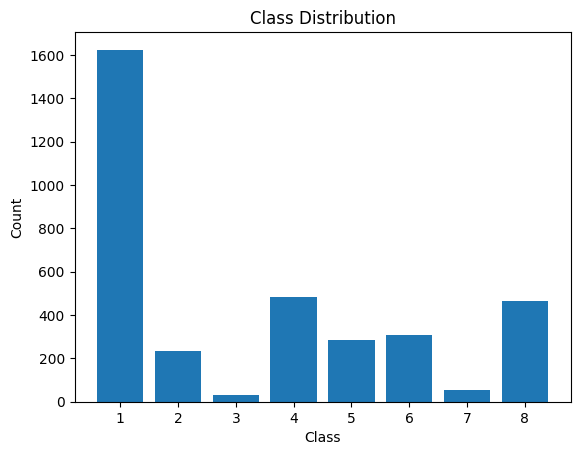

In [3]:
with open("data_labels.csv", "r") as f:
    labels = f.read().splitlines()
    labels = [int(x) for x in labels]

count(labels)

To solve this, we will be using **Synthetic Minority Over-sampling Technique (SMOTE)** to balance the dataset into having a perfectly uniform distribution. The minority classes were duplicated locally in their corresponding feature spaces. The data duplication is performed randomly across neighboring data points of the similar label. Now, all of the classes have the same frequencies of around 1600.

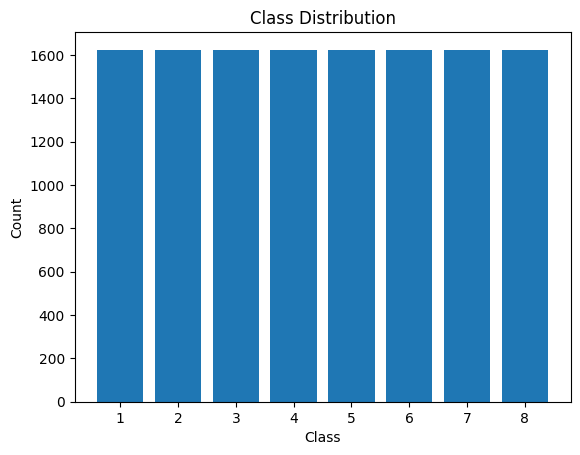

In [4]:
with open("data.csv", "r") as f:
    data = np.loadtxt(f, delimiter=",")

oversampler = SMOTE()
x, y = oversampler.fit_resample(data, labels)
count(y)

We do not have metadata about what the labels represent. However, we are required to perform one-hot encoding on the labels which warrants that our neural network later should have the same number of output nodes as the length of each one-hot encoded label.

In [5]:
def one_hot_encode(labels):
    classes = sorted(set(labels))
    class_to_index = {c: i for i, c in enumerate(classes)}
    one_hot = np.zeros((len(labels), len(classes)))
    for i, label in enumerate(labels):
        one_hot[i, class_to_index[label]] = 1
    return one_hot

y = one_hot_encode(y)

We now randomly partition the balanced dataset into training and test sets. The validation set contains 800 data points.

In [6]:
np.random.seed(922)
indices = np.random.permutation(len(x))
val_indices = indices[:800]
train_indices = indices[800:]

x_train, y_train = x[train_indices], y[train_indices]
x_val, y_val = x[val_indices], y[val_indices]

Since we randomly partitioned the dataset, the class distribution in the validation set isn't perfectly equal but is close in the number of data points of around 100 per class.

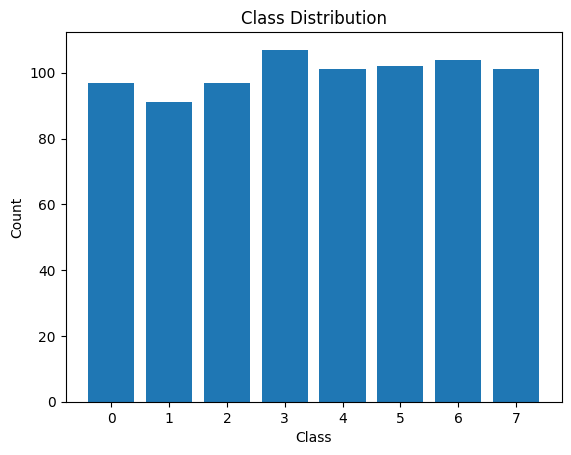

In [7]:
count(np.argmax(y_val, axis=1))

We now save the training set to `training_set.csv` and its labels to `training_labels.csv`, and the validation set to `validation_set.csv` and its labels to `validation_labels.csv`.

In [8]:
with open("training_set.csv", "w") as f:
    np.savetxt(f, x_train, delimiter=",")
with open("training_labels.csv", "w") as f:
    np.savetxt(f, y_train, delimiter=",", fmt="%d")
with open("validation_set.csv", "w") as f:
    np.savetxt(f, x_val, delimiter=",")
with open("validation_labels.csv", "w") as f:
    np.savetxt(f, y_val, delimiter=",", fmt="%d")

The training, validation, and test sets are now ready to be used by our neural network!

## Programming the Neural Network

We now develop the neural network which is just a simple two-layer perceptron network (2-MLP).

### Activation Functions and their Derivatives

We implemented the logistic, hyperbolic tangent, and leaky rectified linear unit activation functions and their gradients in distinct classes with default parameter values. We defined the activation functions as classes that has forward pass method `__call__()` which expects the net internal activity and gradient method `gradient()` to decouple its logic later. The `gradient()` method expects the output $y$ for both $\tanh()$ and $\text{logistic}()$ functions to speed up computation while leaky ReLU expects the net internal activity $v$. This is done to speed up computation.

1. Logistic function

$$
y = \frac{1}{1+e^{-av}} \qquad y' = ay(1-y)
$$

2. Hyperbolic tangent

$$
y = a\tanh{bv} \qquad y' = \frac{b}{a}(a - y)(a + y)
$$

3. Leaky ReLU

$$
y = 
\begin{cases}
v, & v > 0 \\
\alpha v, & v < 0
\end{cases} \qquad

y' = 
\begin{cases}
1, & v > 0 \\
\alpha, & v < 0
\end{cases}
$$

In [9]:
class Logistic:
    def __init__(self, a=2):
        self.a = a

    # y = 1 / (1 + exp(-a * v))
    def __call__(self, v):
        return 1 / (1 + np.exp(-self.a * v))

    # y' = a * y * (1 - y)
    def gradient(self, y):
        return self.a * y * (1 - y)

class Tanh:
    def __init__(self, a=1.716, b=2/3):
        self.a = a
        self.b = b

    # y = a * tanh(b * v)
    def __call__(self, v):
        return self.a * np.tanh(self.b * v)
    
    # y' = (b / a) * (a - y) * (a + y)
    def gradient(self, y):
        return (self.b / self.a) * (self.a - y) * (self.a + y)

class LeakyReLU:
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    # y = v if v > 0 else alpha * v
    def __call__(self, v):
        return np.where(v > 0, v, self.alpha * v)

    # y' = 1 if v > 0 else alpha
    def gradient(self, v):
        mask = (v > 0).astype(float)
        mask[mask == 0] = self.alpha
        return mask

### Perceptron Layer

The perceptron layer simply consists of regular perceptrons, its dimension is defined by the input size and output size. It also has weights that gets updated per batch, and `past_delta` that contains the $\Delta w_{ji}(n-1)$ for Generalized Delta Rule.

In [10]:
class Layer:
    def __init__(self, input_size, output_size):
        self.input_size = input_size
        self.output_size = output_size

        # Add an extra dimension for bias and initialize weights
        self.weights = np.random.randn(input_size + 1, output_size) * 0.01

        self.past_delta = np.zeros_like(self.weights)

### Multi-Layer Perceptron

The multi-layer perceptron (MLP) or artificial neural network (ANN) is implemented in the code below. We follow the sequence of calculating the forward pass then backpropagating the loss using the equations derived from class.v Please note that we are training in mini-batches so the code may deviate a bit.

1. Net internal activity - we solve for the weighted sum of the inputs of each layer starting from the input layer.

$$
v_j(n) = \sum_{i=0}^p w_{ji}(n)\ y_i(n)
$$

2. Output - the output of a layer is the result of applying an activation function to the net internal activity.

$$
y_j(n) = \varphi(v_j(n))
$$

3. Error - the error $e_j(n)$ is calculated by getting the difference between the predicted output and the real output. We also need to save the sum of square errors $\mathcal{E}(n)$ for logging the training error, we obtain the average SSE where $m$ is the batch size.

$$
e_j(n) = d_j(n) - y_j(n)
$$

$$
\mathcal{E}(n)=\frac{1}{2m}\sum_{j\in C} e_j^2(n)
$$


4. Backpropagation - it is the algorithm that allows our neural network to learn by propagating the error through the entire network and updates the weights of each layer. The Delta rule is as follows:

$$
\Delta w_{ji}(n)=\eta\delta_j(n)y_i(n)
$$
where $\delta_j(n)$ is the local gradient defined as,

$$\delta_j{n} =  \begin{cases}

e_j(n)\varphi'(v_j(n)), & \text{for output neurons} \\
\varphi'(v_j(n))\sum_k\delta_k(n)w_{kj}(n), & \text{for hidden neurons}

\end{cases}$$

5. Generalized delta rule - uses the concept of momentum to speed up training by increasing $Delta w_{ji}(n)$ based on how fast the gradients are changing. 

$$
\Delta w_{ji}(n) = \alpha \Delta w_{ji}(n-1) + n\delta_j(n)y_j(n)
$$

In [71]:
class MLP:
    def __init__(self, input_size: int, output_size: int,
                 hidden_layers: list, activations: list, 
                 mini_batch=8, learning_rate=0.01,
                 momentum=0.9, log_interval=5, epochs=100, save_best_weights=False,
                 model_name="MLP", folder_name="results", load_path=None):
        self.activations = activations
        self.mini_batch = mini_batch
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.log_interval = log_interval
        self.epochs = epochs
        self.load_path = load_path
        self.save_best_weights = save_best_weights
        self.model_name = model_name

        self.layers = [Layer(input_size, hidden_layers[0])]
        for layer in range(1, len(hidden_layers)):
            self.layers.append(Layer(hidden_layers[layer - 1], hidden_layers[layer]))
        self.layers.append(Layer(hidden_layers[-1], output_size))
        
        self.training_sse_history = []
        self.val_sse_history = []
        self.metrics = {}

        self.results_path = os.path.join(os.getcwd(), folder_name, model_name)
        os.makedirs(self.results_path, exist_ok=True)

        if self.load_path:
            self.load_weights(self.load_path)
        
    def forward(self, x):
        # We will store pre-activations and post-activations for use in the backward pass
        self.vs = [] 
        self.ys = [x] # post-activation of the input layer is just the input itself
        
        # Forward pass through each layer
        current_input = x
        for layer, activation in zip(self.layers, self.activations):
            v = np.dot(current_input, layer.weights[1:]) + layer.weights[0]
            self.vs.append(v)
            
            current_input = activation(v)
            self.ys.append(current_input)

        return current_input
    
    def compute_error(self, label):
        prediction = self.ys[-1]
        e = label - prediction 

        # Calculate the average sum of squared errors
        sse = 0.5 * np.sum(e ** 2) / label.shape[0]

        return e, sse

    def backward(self, label):   
        m = label.shape[0]
        e, sse = self.compute_error(label)

        # Backpropagate the error through the layers
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            activation = self.activations[i]
            v = self.vs[i] # net internal activity of this layer
            y_i = self.ys[i] # input of this layer
            y_j = self.ys[i+1] # output of this layer

            # Calculate the local delta for this layer
            # to save computation, we use y for logistic and tanh
            if type(activation) == LeakyReLU:
                local_delta = e * activation.gradient(v)
            else:
                local_delta = e * activation.gradient(y_j) # use post-activation of this layer for logistic and tanh

            # Since our bias terms are in the first row, we pad y with 1s for gradient calculation
            y_i = np.hstack([np.ones((m, 1)), y_i]) # add bias term to input

            # Calculate the gradient of the loss with respect to the weights
            weight_gradient = np.dot(y_i.T, local_delta) / m

            # Propagate the error to the previous layer for the next iteration of backpropagation
            e = np.dot(local_delta, layer.weights[1:].T)

            # Calculate generalized delta rule with past delta for momentum
            layer.past_delta = self.momentum * layer.past_delta + self.learning_rate * weight_gradient
            layer.weights += layer.past_delta

        return sse


    def train(self, x_train, y_train, x_val, y_val):
        # Train the neural network and save results to file
        for epoch in range(self.epochs):
            epoch_sse = 0
            for i in range(0, len(x_train), self.mini_batch):
                batch_x = x_train[i:i+self.mini_batch]
                batch_y = y_train[i:i+self.mini_batch]

                self.forward(batch_x)
                sse = self.backward(batch_y)
                epoch_sse += sse

            avg_train_sse = epoch_sse / (len(x_train) / self.mini_batch)
            self.training_sse_history.append([epoch, avg_train_sse])

            # We log the SSE at the end of each epoch by log interval
            if epoch % self.log_interval == 0 or epoch == self.epochs - 1:
                # Calculate validation error
                self.forward(x_val)
                val_sse = self.compute_error(y_val)[1]

                predictions = np.argmax(self.ys[-1], axis=1)
                labels = np.argmax(y_val, axis=1)

                misclassified = len(labels) - np.sum(predictions == labels)

                self.val_sse_history.append([epoch, val_sse, misclassified])

                # If validation SSE is the best we've seen, save the weights
                if self.save_best_weights:
                    if val_sse == min(s[1] for s in self.val_sse_history):
                        self.save_weights(f"{self.results_path}/best_weights.csv")

            print(f"Epoch {epoch}/{self.epochs}, SSE(train): {avg_train_sse:.4f}")

        # Save results to file
        with open(f"{self.results_path}/training_sse.csv", "w") as f:
            self.training_sse_history = np.array(self.training_sse_history)
            np.savetxt(f, self.training_sse_history, delimiter=",", fmt="%d,%f")

        with open(f"{self.results_path}/validation_sse.csv", "w") as f:
            self.val_sse_history = np.array(self.val_sse_history)
            np.savetxt(f, self.val_sse_history, delimiter=",", fmt="%d,%f,%d")
        
        # Save final weights after training
        self.save_weights(f"{self.results_path}/final_weights.csv")

    def run(self, x):
        # Run the neural network on the input and return predictions
        predictions = self.forward(x)

        # Recover class labels from one-hot encoding
        predictions = np.argmax(predictions, axis=1)

        return predictions
    
    def evaluate(self, x, y):
        predictions = self.run(x)

        labels = np.argmax(y, axis=1)
        num_classes = y.shape[1]
        conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

        for true_label, pred_label in zip(labels, predictions):
            conf_matrix[true_label, pred_label] += 1
        
        tps = np.diag(conf_matrix)
        n = len(labels)
        c = np.sum(tps)

        rt = np.sum(conf_matrix, axis=1) # sum of columns
        ct = np.sum(conf_matrix, axis=0) # sum of rows
        
        misclassified = n - c # save this 
        accuracy = c / n

# Force the output arrays to be floats to accept the division results
        precisions = np.divide(tps, ct, out=np.zeros_like(tps, dtype=float), where=ct != 0)
        recalls = np.divide(tps, rt, out=np.zeros_like(tps, dtype=float), where=rt != 0)
        f1_denom = precisions + recalls
        f1s = np.divide(2 * precisions * recalls, f1_denom, out=np.zeros_like(tps, dtype=float), where=f1_denom != 0)
        # MCC

        mcc = (c * n - np.dot(rt, ct)) / np.sqrt((n**2 - np.dot(rt, rt)) * ((n**2 - np.dot(ct, ct))))

        self.metrics = {
            "confusion_matrix": conf_matrix,
            "misclassified": misclassified,
            "accuracy": accuracy,
            "precision": precisions,
            "recall": recalls,
            "f1_score": f1s,
            "mcc": mcc,
        }

        # Save metrics to file
        with open(f"{self.results_path}/confusion_matrix.csv", "w") as f:
            np.savetxt(f, conf_matrix, delimiter=",", fmt="%d")
        
        with open(f"{self.results_path}/metrics.csv", "w") as f:
            f.write("metric,value\n")
            f.write(f"misclassified,{misclassified}\n")
            f.write(f"accuracy,{accuracy}\n")
            f.write(f"mcc,{mcc}\n")
            for i in range(len(precisions)):
                f.write(f"precision_class_{i},{precisions[i]}\n")
                f.write(f"recall_class_{i},{recalls[i]}\n")
                f.write(f"f1_score_class_{i},{f1s[i]}\n")

        return self.metrics

    def save_weights(self, path):
        weights = np.concatenate([layer.weights.flatten() for layer in self.layers])
        np.savetxt(path, weights, delimiter=",")

        print(f"Weights saved to {path}")

    def load_weights(self, load_path):
        all_weights = np.loadtxt(load_path, delimiter=",")
        
        current_index = 0
        for layer in self.layers:
            # Calculate the exact dimensions for this specific layer
            rows = layer.input_size + 1
            cols = layer.output_size
            num_elements = rows * cols
            
            # Slice the exact chunk of numbers needed for this layer
            chunk = all_weights[current_index : current_index + num_elements]
            
            # Reshape the 1D chunk back into the proper 2D matrix
            layer.weights = chunk.reshape((rows, cols))
            
            # Move the index forward for the next layer's slice
            current_index += num_elements
            
        print(f"Weights successfully loaded and mapped from {self.load_path}")


### Tanh-Tanh-Logistic Network vs. Leaky-Leaky-Logistic Network

We compare the training and validation losses of the tanh-tanh-logistic network and the leaky-leaky-logistic network. We use the same hyperparameters except the activation function used.

In [42]:
lll = MLP(
    model_name = f"leaky-leaky-logistic-100-100",
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[LeakyReLU(), LeakyReLU(), Logistic()],
    epochs=100
)

lll.train(x_train, y_train, x_val, y_val)

ttl = MLP(
    model_name = f"tanh-tanh-logistic-100-100",
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[Tanh(), Tanh(), Logistic()],
    epochs=100
)

ttl.train(x_train, y_train, x_val, y_val)

Epoch 0/100, SSE(train): 0.4476
Epoch 1/100, SSE(train): 0.4375
Epoch 2/100, SSE(train): 0.4361
Epoch 3/100, SSE(train): 0.3694
Epoch 4/100, SSE(train): 0.2573
Epoch 5/100, SSE(train): 0.2123
Epoch 6/100, SSE(train): 0.1721
Epoch 7/100, SSE(train): 0.1446
Epoch 8/100, SSE(train): 0.1212
Epoch 9/100, SSE(train): 0.0928
Epoch 10/100, SSE(train): 0.0740
Epoch 11/100, SSE(train): 0.0626
Epoch 12/100, SSE(train): 0.0550
Epoch 13/100, SSE(train): 0.0502
Epoch 14/100, SSE(train): 0.0457
Epoch 15/100, SSE(train): 0.0419
Epoch 16/100, SSE(train): 0.0380
Epoch 17/100, SSE(train): 0.0348
Epoch 18/100, SSE(train): 0.0321
Epoch 19/100, SSE(train): 0.0303
Epoch 20/100, SSE(train): 0.0286
Epoch 21/100, SSE(train): 0.0273
Epoch 22/100, SSE(train): 0.0255
Epoch 23/100, SSE(train): 0.0245
Epoch 24/100, SSE(train): 0.0228
Epoch 25/100, SSE(train): 0.0217
Epoch 26/100, SSE(train): 0.0210
Epoch 27/100, SSE(train): 0.0203
Epoch 28/100, SSE(train): 0.0187
Epoch 29/100, SSE(train): 0.0183
Epoch 30/100, SSE(tr

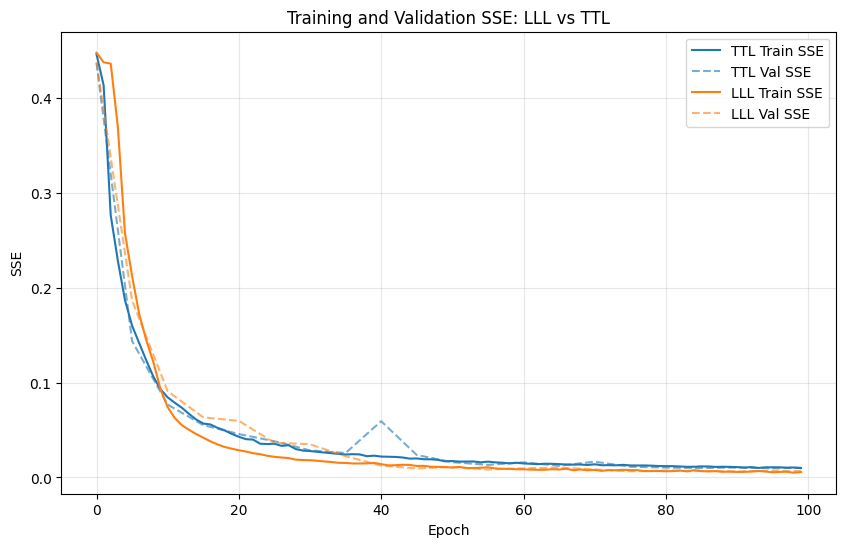

In [43]:
plt.figure(figsize=(10, 6))

# Plot TTL (Tanh) - Blue lines
plt.plot(ttl.training_sse_history[:, 0], ttl.training_sse_history[:, 1], linestyle='-', label='TTL Train SSE')
plt.plot(ttl.val_sse_history[:, 0], ttl.val_sse_history[:, 1], color='tab:blue', linestyle='--', alpha=0.6, label='TTL Val SSE')

# Plot LLL (Leaky ReLU) - Orange lines
plt.plot(lll.training_sse_history[:, 0], lll.training_sse_history[:, 1], color='tab:orange', linestyle='-', label='LLL Train SSE')
plt.plot(lll.val_sse_history[:, 0], lll.val_sse_history[:, 1], color='tab:orange', linestyle='--', alpha=0.6, label='LLL Val SSE')

plt.xlabel('Epoch')
plt.ylabel('SSE')
plt.title('Training and Validation SSE: LLL vs TTL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

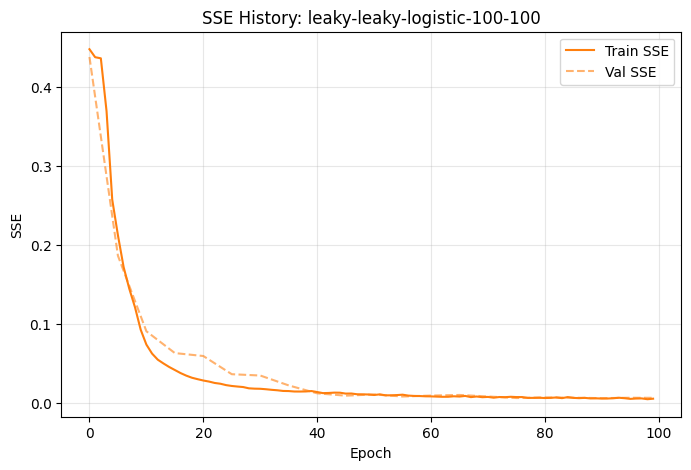

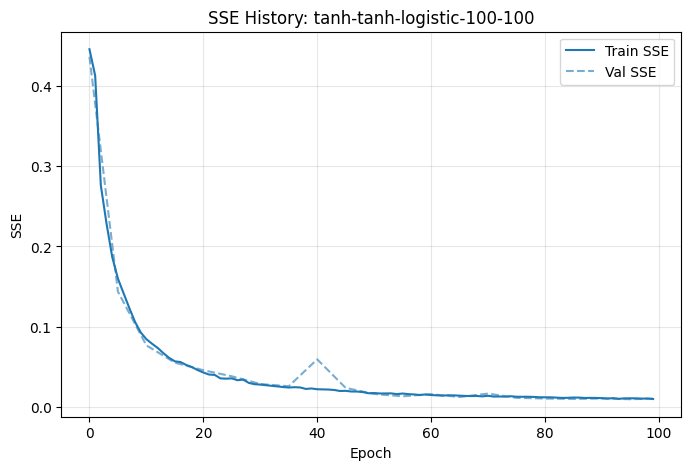

In [46]:
def plot_individual_history(model, color):
    plt.figure(figsize=(8, 5))
    
    plt.plot(model.training_sse_history[:, 0], model.training_sse_history[:, 1], 
             color=color, linestyle='-', label='Train SSE')
    plt.plot(model.val_sse_history[:, 0], model.val_sse_history[:, 1], 
             color=color, linestyle='--', alpha=0.6, label='Val SSE')
    
    plt.xlabel('Epoch')
    plt.ylabel('SSE')
    plt.title(f'SSE History: {model.model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_individual_history(lll, color='tab:orange')
plot_individual_history(ttl, color='tab:blue')

#### By Hidden Layer Neurons

We will run the two networks with 20 epochs per run across different number of neurons per hidden layer with a mini-batch of 8.

In [50]:
neurons = [[100, 100], [200, 200], [300, 300], [400, 400]]
errors = []

for neuron in neurons:

    ttl = MLP(
        model_name = f"tanh-tanh-logistic-{neuron[0]}-{neuron[1]}-20epochs",
        input_size=354,
        output_size=8,
        hidden_layers=neuron,
        activations=[Tanh(), Tanh(), Logistic()],
        mini_batch=8,
        epochs=20
    )
    
    ttl.train(x_train, y_train, x_val, y_val)

    lll = MLP(
        model_name = f"leaky-leaky-logistic-{neuron[0]}-{neuron[1]}-20epochs",
        input_size=354,
        output_size=8,
        hidden_layers=neuron,
        activations=[LeakyReLU(), LeakyReLU(), Logistic()],
        mini_batch=8,
        epochs=20
    )
    
    lll.train(x_train, y_train, x_val, y_val)
    
    errors.append([neuron, [ttl.training_sse_history[-1][1], ttl.val_sse_history[-1][1]],
                   [lll.training_sse_history[-1][1], lll.val_sse_history[-1][1]]])



Epoch 0/20, SSE(train): 0.4475
Epoch 1/20, SSE(train): 0.4374
Epoch 2/20, SSE(train): 0.4276
Epoch 3/20, SSE(train): 0.3007
Epoch 4/20, SSE(train): 0.2522
Epoch 5/20, SSE(train): 0.2388
Epoch 6/20, SSE(train): 0.2027
Epoch 7/20, SSE(train): 0.1655
Epoch 8/20, SSE(train): 0.1457
Epoch 9/20, SSE(train): 0.1313
Epoch 10/20, SSE(train): 0.1130
Epoch 11/20, SSE(train): 0.0938
Epoch 12/20, SSE(train): 0.0797
Epoch 13/20, SSE(train): 0.0711
Epoch 14/20, SSE(train): 0.0642
Epoch 15/20, SSE(train): 0.0588
Epoch 16/20, SSE(train): 0.0548
Epoch 17/20, SSE(train): 0.0523
Epoch 18/20, SSE(train): 0.0489
Epoch 19/20, SSE(train): 0.0458
Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-100-100-20epochs/final_weights.csv
Epoch 0/20, SSE(train): 0.4480
Epoch 1/20, SSE(train): 0.4377
Epoch 2/20, SSE(train): 0.4376
Epoch 3/20, SSE(train): 0.4374
Epoch 4/20, SSE(train): 0.4347
Epoch 5/20, SSE(train): 0.3904
Epoch 6/20, SSE(train): 0.3167
Epoch 7/20, SSE(train): 0.2384
Epoch 8

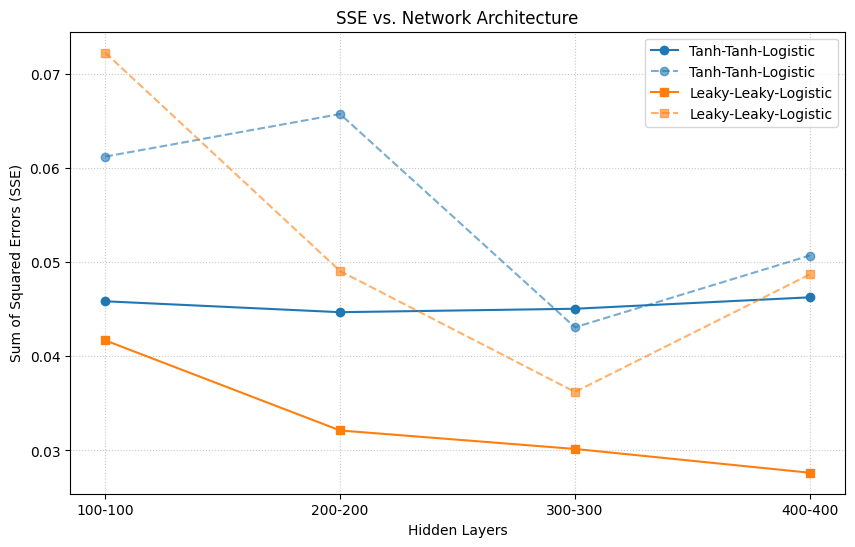

In [53]:
# Create x-axis labels from the neuron list (e.g., "100-100")
labels = [f"{n[0]}-{n[1]}" for n, _, _ in errors]
ttl_train_errors = [ttl_sse[0] for _, ttl_sse, _ in errors]
ttl_val_errors = [ttl_sse[1] for _, ttl_sse, _ in errors]
lll_train_errors = [lll_sse[0] for _, _, lll_sse in errors]
lll_val_errors = [lll_sse[1] for _, _, lll_sse in errors]

plt.figure(figsize=(10, 6))
plt.plot(labels, ttl_train_errors, label='Tanh-Tanh-Logistic', 
         color="tab:blue", marker='o', linestyle='-')
plt.plot(labels, ttl_val_errors, label='Tanh-Tanh-Logistic', 
         color="tab:blue", alpha=0.6, marker='o', linestyle='--')
plt.plot(labels, lll_train_errors, label='Leaky-Leaky-Logistic',
         color="tab:orange", marker='s', linestyle='-')
plt.plot(labels, lll_val_errors, label='Leaky-Leaky-Logistic',
         color="tab:orange", alpha=0.6, marker='s', linestyle='--')

plt.xlabel("Hidden Layers")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.title("SSE vs. Network Architecture")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

#### By Training Time

We will run the two networks with 20 epochs per run across different mini-batch sizes which are [8, 16, 32, 64, 128].

In [54]:
mini_batches = [8, 16, 32, 64, 128]
training_times = []

for mini_batch in mini_batches:
    start_time = time.time()
    MLP(
        model_name = f"tanh-tanh-logistic-100-100-20epochs-mini_batch-{mini_batch}",
        input_size=354,
        output_size=8,
        hidden_layers=[100, 100],
        activations=[Tanh(), Tanh(), Logistic()],
        mini_batch=mini_batch,
        epochs=20
    ).train(x_train, y_train, x_val, y_val)
    ttl_time = (time.time() - start_time) / 20

    start_time = time.time()
    MLP(
        model_name = f"leaky-leaky-logistic-100-100-20epochs-mini_batch-{mini_batch}",
        input_size=354,
        output_size=8,
        hidden_layers=[100, 100],
        activations=[LeakyReLU(), LeakyReLU(), Logistic()],
        mini_batch=mini_batch,
        epochs=20
    ).train(x_train, y_train, x_val, y_val)
    lll_time = (time.time() - start_time) / 20

    training_times.append([mini_batch, ttl_time, lll_time])

with open(f"results/mini_batch_training_times.csv", "w") as f:
    f.write("mini_batch,tanh-tanh-logistic_time,leaky-leaky-logistic_time\n")
    for mini_batch, ttl_time, lll_time in training_times:
        f.write(f"{mini_batch},{ttl_time:.4f},{lll_time:.4f}\n")


Epoch 0/20, SSE(train): 0.4474
Epoch 1/20, SSE(train): 0.4375
Epoch 2/20, SSE(train): 0.4331
Epoch 3/20, SSE(train): 0.3212
Epoch 4/20, SSE(train): 0.2550
Epoch 5/20, SSE(train): 0.2428
Epoch 6/20, SSE(train): 0.2303
Epoch 7/20, SSE(train): 0.1896
Epoch 8/20, SSE(train): 0.1544
Epoch 9/20, SSE(train): 0.1394
Epoch 10/20, SSE(train): 0.1195
Epoch 11/20, SSE(train): 0.0939
Epoch 12/20, SSE(train): 0.0791
Epoch 13/20, SSE(train): 0.0711
Epoch 14/20, SSE(train): 0.0650
Epoch 15/20, SSE(train): 0.0587
Epoch 16/20, SSE(train): 0.0547
Epoch 17/20, SSE(train): 0.0513
Epoch 18/20, SSE(train): 0.0479
Epoch 19/20, SSE(train): 0.0446
Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-100-100-20epochs-mini_batch-8/final_weights.csv
Epoch 0/20, SSE(train): 0.4482
Epoch 1/20, SSE(train): 0.4377
Epoch 2/20, SSE(train): 0.4377
Epoch 3/20, SSE(train): 0.4376
Epoch 4/20, SSE(train): 0.4375
Epoch 5/20, SSE(train): 0.4363
Epoch 6/20, SSE(train): 0.3846
Epoch 7/20, SSE(train): 0

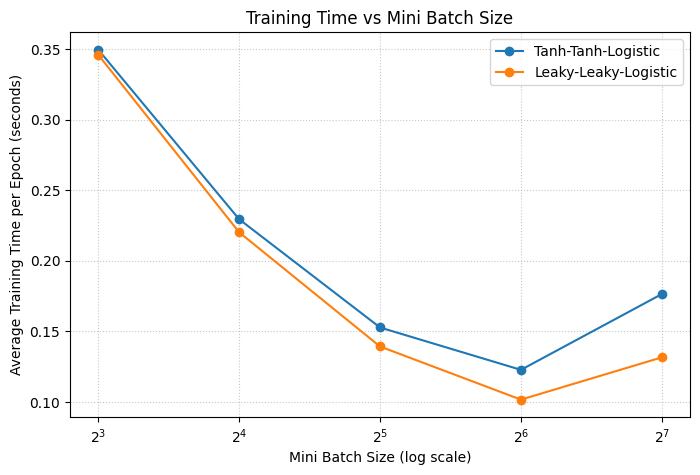

In [55]:
plt.figure(figsize=(8, 5))
plt.plot([t[0] for t in training_times], [t[1] for t in training_times], label='Tanh-Tanh-Logistic', marker='o')
plt.plot([t[0] for t in training_times], [t[2] for t in training_times], label='Leaky-Leaky-Logistic', marker='o')
plt.xscale('log', base=2)
plt.xlabel("Mini Batch Size (log scale)")
plt.ylabel("Average Training Time per Epoch (seconds)")
plt.title("Training Time vs Mini Batch Size")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Convergence and Hyperparameter Tuning

We will test the effect of learning rate and momentum on convergence.

#### Learning Rate on Convergence

We use a light ReLU-based model containing [100, 100] hidden layers to determine the effects of learning rate on model convergence. This is to save compute and training time. We will be experimenting on a constant momentum factor of 0.9 and learning rates [0.005, 0.01, 0.05, 0.1] across 50 epochs.

In [56]:
lrs = [0.005, 0.01, 0.05, 0.1]
errors = []

# Dictionary to store the full epoch histories for each learning rate
histories = {}

for lr in lrs:
    ttl = MLP(
        model_name = f"tanh-tanh-logistic-100-100-50epochs-lr-{lr}",
        input_size=354,
        output_size=8,
        hidden_layers=[100, 100],
        activations=[Tanh(), Tanh(), Logistic()],
        mini_batch=8,
        epochs=50,
        learning_rate=lr,
    )
    ttl.train(x_train, y_train, x_val, y_val)

    # 1. Save final errors for the CSV
    errors.append([lr, ttl.training_sse_history[-1][1], ttl.val_sse_history[-1][1]])
    
    # 2. Save the full histories to our dictionary for plotting
    histories[lr] = {
        'train': ttl.training_sse_history,
        'val': ttl.val_sse_history
    }

# Write final numbers to CSV
with open(f"results/lr_errors.csv", "w") as f:
    f.write("lr,training_error,validation_error\n")
    for lr, train_error, val_error in errors:
        f.write(f"{lr},{train_error:.4f},{val_error:.4f}\n")

Epoch 0/50, SSE(train): 0.4555
Epoch 1/50, SSE(train): 0.4376
Epoch 2/50, SSE(train): 0.4375
Epoch 3/50, SSE(train): 0.4373
Epoch 4/50, SSE(train): 0.4367
Epoch 5/50, SSE(train): 0.4324
Epoch 6/50, SSE(train): 0.3631
Epoch 7/50, SSE(train): 0.2790
Epoch 8/50, SSE(train): 0.2558
Epoch 9/50, SSE(train): 0.2477
Epoch 10/50, SSE(train): 0.2422
Epoch 11/50, SSE(train): 0.2356
Epoch 12/50, SSE(train): 0.2219
Epoch 13/50, SSE(train): 0.1950
Epoch 14/50, SSE(train): 0.1740
Epoch 15/50, SSE(train): 0.1589
Epoch 16/50, SSE(train): 0.1501
Epoch 17/50, SSE(train): 0.1447
Epoch 18/50, SSE(train): 0.1397
Epoch 19/50, SSE(train): 0.1337
Epoch 20/50, SSE(train): 0.1265
Epoch 21/50, SSE(train): 0.1186
Epoch 22/50, SSE(train): 0.1097
Epoch 23/50, SSE(train): 0.0982
Epoch 24/50, SSE(train): 0.0857
Epoch 25/50, SSE(train): 0.0750
Epoch 26/50, SSE(train): 0.0674
Epoch 27/50, SSE(train): 0.0618
Epoch 28/50, SSE(train): 0.0576
Epoch 29/50, SSE(train): 0.0542
Epoch 30/50, SSE(train): 0.0514
Epoch 31/50, SSE(t

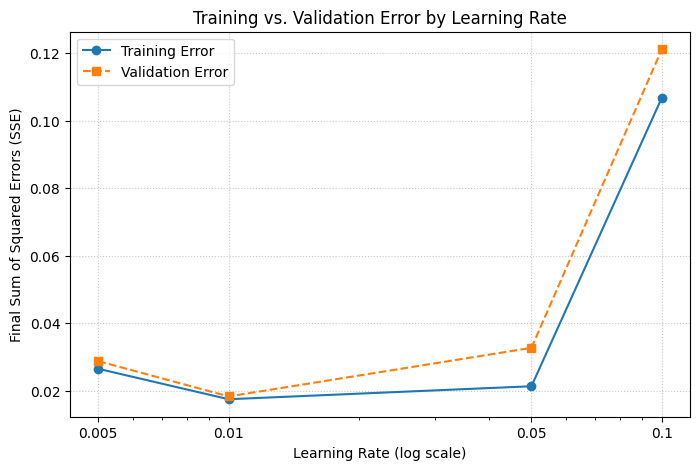

In [57]:
# Extract the data from your 'errors' list
x_lrs = [item[0] for item in errors]
y_train_err = [item[1] for item in errors]
y_val_err = [item[2] for item in errors]

plt.figure(figsize=(8, 5))

# Plot Training Error (solid blue line with circles)
plt.plot(x_lrs, y_train_err, label='Training Error', marker='o', linestyle='-')

# Plot Validation Error (dashed orange line with squares)
plt.plot(x_lrs, y_val_err, label='Validation Error', marker='s', linestyle='--')

# Set the x-axis to a logarithmic scale
plt.xscale('log')

# Force matplotlib to display your exact learning rates on the x-axis ticks
plt.xticks(x_lrs, x_lrs)

# Add labels, title, and legend
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Final Sum of Squared Errors (SSE)")
plt.title("Training vs. Validation Error by Learning Rate")
plt.legend()

# Add a subtle grid for easier reading
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

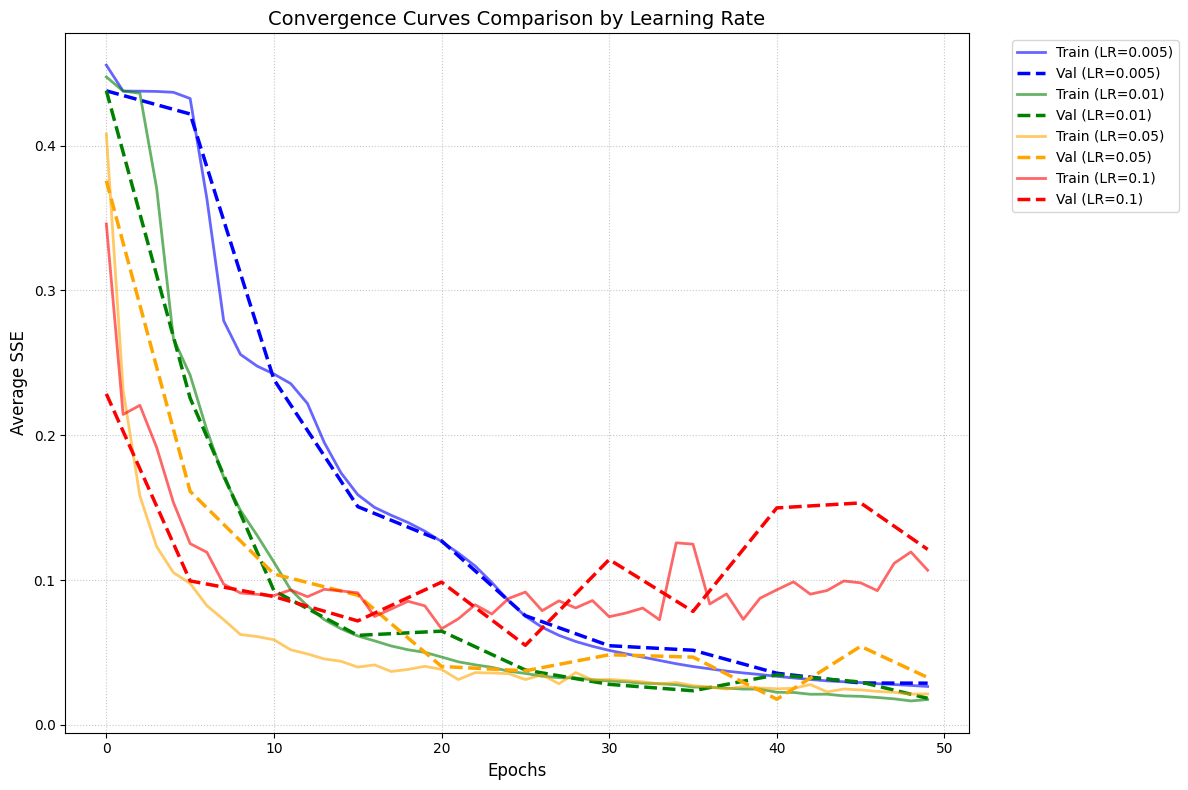

In [58]:
def plot_lr_convergence_comparison(histories):
    plt.figure(figsize=(12, 8))
    
    # Assign a specific color to each learning rate for visual consistency
    colors = {0.005: 'blue', 0.01: 'green', 0.05: 'orange', 0.1: 'red'}
    
    for lr, hist in histories.items():
        # Convert histories to numpy arrays for easy column slicing
        train_sse = np.array(hist['train'])
        val_sse = np.array(hist['val'])
        
        # Determine the color based on the dictionary above (default to purple if not found)
        line_color = colors.get(lr, 'purple')

        # Plot Training SSE (Solid Line, slightly transparent so lines don't block each other)
        plt.plot(train_sse[:, 0], train_sse[:, 1], 
                 label=f'Train (LR={lr})', color=line_color, linestyle='-', alpha=0.6, linewidth=2)
        
        # Plot Validation SSE (Dashed Line, fully opaque to stand out)
        plt.plot(val_sse[:, 0], val_sse[:, 1], 
                 label=f'Val (LR={lr})', color=line_color, linestyle='--', alpha=1.0, linewidth=2.5)

    # Add labels and styling
    plt.title('Convergence Curves Comparison by Learning Rate', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Average SSE', fontsize=12)
    
    # Move the legend outside the plot box so it doesn't cover up your data
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout() # Ensures the external legend fits in the exported image
    plt.show()

# Call the function using the dictionary you just generated
plot_lr_convergence_comparison(histories)

#### Momentum on Convergence

We again use the same experimental configurations as we did with the learning rate but now we set the learning rate to the best learning rate we observed which is 0.05. We then experiment on different momentum factors [0.1, 0.5, 0.75, 0.9]. 

In [59]:
momentums = [0.1, 0.5, 0.75, 0.9]
errors = []

# Dictionary to store the full epoch histories for each momentum value
histories = {}

for momentum in momentums:
    ttl = MLP(
        model_name = f"tanh-tanh-logistic-100-100-50epochs-momentum-{momentum}", # Updated to 50epochs
        input_size=354,
        output_size=8,
        hidden_layers=[100, 100],
        activations=[Tanh(), Tanh(), Logistic()],
        mini_batch=8,
        epochs=50,
        learning_rate=0.01,
        momentum=momentum,
    )
    ttl.train(x_train, y_train, x_val, y_val)

    # 1. Save final errors for the CSV
    errors.append([momentum, ttl.training_sse_history[-1][1], ttl.val_sse_history[-1][1]])
    
    # 2. Save the full histories to our dictionary for plotting
    histories[momentum] = {
        'train': ttl.training_sse_history,
        'val': ttl.val_sse_history
    }

# Write final numbers to CSV
with open(f"results/momentum_errors.csv", "w") as f:
    f.write("momentum,training_error,validation_error\n")
    for momentum, train_error, val_error in errors:
        f.write(f"{momentum},{train_error:.4f},{val_error:.4f}\n")

Epoch 0/50, SSE(train): 0.5071
Epoch 1/50, SSE(train): 0.4376
Epoch 2/50, SSE(train): 0.4375
Epoch 3/50, SSE(train): 0.4375
Epoch 4/50, SSE(train): 0.4375
Epoch 5/50, SSE(train): 0.4375
Epoch 6/50, SSE(train): 0.4375
Epoch 7/50, SSE(train): 0.4375
Epoch 8/50, SSE(train): 0.4374
Epoch 9/50, SSE(train): 0.4374
Epoch 10/50, SSE(train): 0.4374
Epoch 11/50, SSE(train): 0.4374
Epoch 12/50, SSE(train): 0.4373
Epoch 13/50, SSE(train): 0.4373
Epoch 14/50, SSE(train): 0.4372
Epoch 15/50, SSE(train): 0.4371
Epoch 16/50, SSE(train): 0.4370
Epoch 17/50, SSE(train): 0.4369
Epoch 18/50, SSE(train): 0.4367
Epoch 19/50, SSE(train): 0.4365
Epoch 20/50, SSE(train): 0.4362
Epoch 21/50, SSE(train): 0.4356
Epoch 22/50, SSE(train): 0.4348
Epoch 23/50, SSE(train): 0.4333
Epoch 24/50, SSE(train): 0.4303
Epoch 25/50, SSE(train): 0.4229
Epoch 26/50, SSE(train): 0.4078
Epoch 27/50, SSE(train): 0.3853
Epoch 28/50, SSE(train): 0.3519
Epoch 29/50, SSE(train): 0.3246
Epoch 30/50, SSE(train): 0.3025
Epoch 31/50, SSE(t

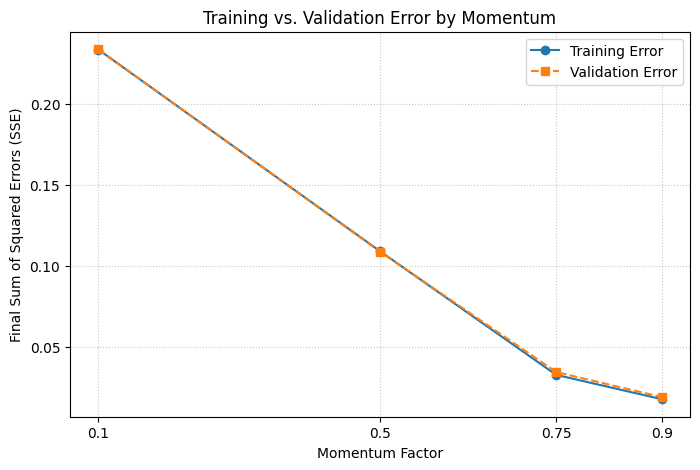

In [60]:
# Extract the data
x_moms = [item[0] for item in errors]
y_train_err = [item[1] for item in errors]
y_val_err = [item[2] for item in errors]

plt.figure(figsize=(8, 5))

# Plot Training Error (solid blue line with circles)
plt.plot(x_moms, y_train_err, label='Training Error', marker='o', linestyle='-')

# Plot Validation Error (dashed orange line with squares)
plt.plot(x_moms, y_val_err, label='Validation Error', marker='s', linestyle='--')

# Ensure all your specific momentum values show up on the x-axis
plt.xticks(x_moms, x_moms)

# Add labels, title, and legend
plt.xlabel("Momentum Factor")
plt.ylabel("Final Sum of Squared Errors (SSE)")
plt.title("Training vs. Validation Error by Momentum")
plt.legend()

plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

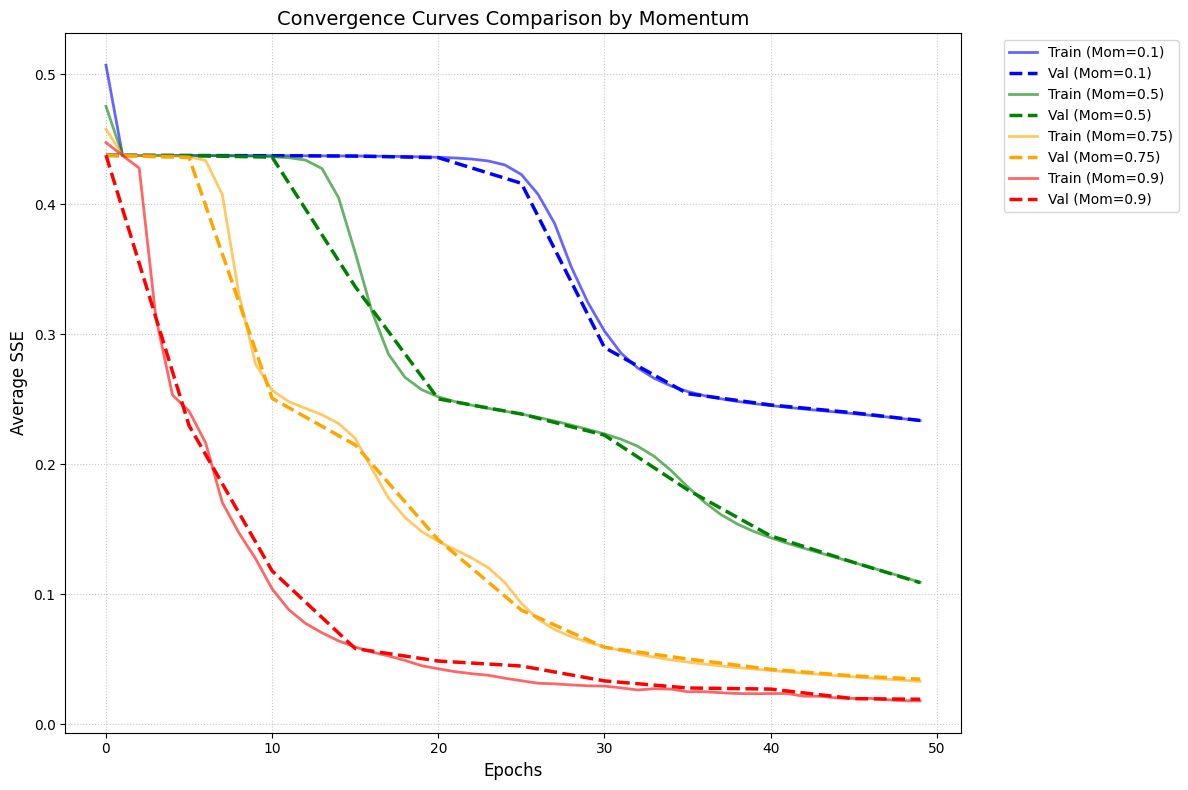

In [61]:
def plot_momentum_convergence_comparison(histories):
    plt.figure(figsize=(12, 8))
    
    # Assign a specific color to each momentum factor
    colors = {0.1: 'blue', 0.5: 'green', 0.75: 'orange', 0.9: 'red'}
    
    for mom, hist in histories.items():
        # Convert histories to numpy arrays for slicing
        train_sse = np.array(hist['train'])
        val_sse = np.array(hist['val'])
        
        # Grab the assigned color
        line_color = colors.get(mom, 'purple')

        # Plot Training SSE (Solid Line)
        plt.plot(train_sse[:, 0], train_sse[:, 1], 
                 label=f'Train (Mom={mom})', color=line_color, linestyle='-', alpha=0.6, linewidth=2)
        
        # Plot Validation SSE (Dashed Line)
        plt.plot(val_sse[:, 0], val_sse[:, 1], 
                 label=f'Val (Mom={mom})', color=line_color, linestyle='--', alpha=1.0, linewidth=2.5)

    # Add labels and styling
    plt.title('Convergence Curves Comparison by Momentum', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Average SSE', fontsize=12)
    
    # Place legend outside the main graph area
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout() # Prevents the legend from getting cut off
    plt.show()

# Generate the plot
plot_momentum_convergence_comparison(histories)

### Best Models

From our previous experimentation, we realized that the Leaky ReLU network performs better and trains faster than the tanh network. From our other experiments, we realized that 0.01 is a good learning rate which can be observed to achieve local minimum without significant fluctuations. Additionally, we found out that 0.9 is the best momentum factor for the given parameters as it produced the lowest errors. We also saw that a model with 300x300 hidden layers produced the lowest errors without overfitting to the training data. We now combine these and train a model with the given parameters.

In [72]:
best_leaky_model = MLP(
    model_name = f"leaky-leaky-logistic-300-300-best",
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[LeakyReLU(), LeakyReLU(), Logistic()],
    mini_batch=64,
    epochs=100,
    save_best_weights=True,
    learning_rate=0.01,
    momentum=0.9,
)

best_leaky_model.train(x_train, y_train, x_val, y_val)

Weights saved to /home/elis/Projects/School/ai201/nn/results/leaky-leaky-logistic-300-300-best/best_weights.csv
Epoch 0/100, SSE(train): 0.5179
Epoch 1/100, SSE(train): 0.4385
Epoch 2/100, SSE(train): 0.4384
Epoch 3/100, SSE(train): 0.4383
Epoch 4/100, SSE(train): 0.4383
Weights saved to /home/elis/Projects/School/ai201/nn/results/leaky-leaky-logistic-300-300-best/best_weights.csv
Epoch 5/100, SSE(train): 0.4383
Epoch 6/100, SSE(train): 0.4383
Epoch 7/100, SSE(train): 0.4383
Epoch 8/100, SSE(train): 0.4382
Epoch 9/100, SSE(train): 0.4382
Weights saved to /home/elis/Projects/School/ai201/nn/results/leaky-leaky-logistic-300-300-best/best_weights.csv
Epoch 10/100, SSE(train): 0.4382
Epoch 11/100, SSE(train): 0.4381
Epoch 12/100, SSE(train): 0.4381
Epoch 13/100, SSE(train): 0.4380
Epoch 14/100, SSE(train): 0.4379
Weights saved to /home/elis/Projects/School/ai201/nn/results/leaky-leaky-logistic-300-300-best/best_weights.csv
Epoch 15/100, SSE(train): 0.4378
Epoch 16/100, SSE(train): 0.4376
E

In [73]:
best_leaky_model.evaluate(x_val, y_val)

{'confusion_matrix': array([[ 94,   0,   0,   0,   0,   3,   0,   0],
        [  0,  90,   1,   0,   0,   0,   0,   0],
        [  0,   0,  97,   0,   0,   0,   0,   0],
        [  0,   0,   0, 107,   0,   0,   0,   0],
        [  0,   0,   0,   0, 101,   0,   0,   0],
        [  4,   0,   0,   0,   0,  93,   2,   3],
        [  0,   0,   0,   0,   0,   0, 104,   0],
        [  0,   1,   1,   2,   0,   5,   1,  91]]),
 'misclassified': np.int64(23),
 'accuracy': np.float64(0.97125),
 'precision': array([0.95918367, 0.98901099, 0.97979798, 0.98165138, 1.        ,
        0.92079208, 0.97196262, 0.96808511]),
 'recall': array([0.96907216, 0.98901099, 1.        , 1.        , 1.        ,
        0.91176471, 1.        , 0.9009901 ]),
 'f1_score': array([0.96410256, 0.98901099, 0.98979592, 0.99074074, 1.        ,
        0.91625616, 0.98578199, 0.93333333]),
 'mcc': np.float64(0.9671911536579973)}

In [74]:
best_tanh_model = MLP(
    model_name = f"tanh-tanh-logistic-300-300-best",
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[Tanh(), Tanh(), Logistic()],
    mini_batch=64,
    epochs=100,
    save_best_weights=True,
    learning_rate=0.01,
    momentum=0.9,
)

best_tanh_model.train(x_train, y_train, x_val, y_val)

Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-300-300-best/best_weights.csv
Epoch 0/100, SSE(train): 0.5041
Epoch 1/100, SSE(train): 0.4383
Epoch 2/100, SSE(train): 0.4382
Epoch 3/100, SSE(train): 0.4382
Epoch 4/100, SSE(train): 0.4380
Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-300-300-best/best_weights.csv
Epoch 5/100, SSE(train): 0.4379
Epoch 6/100, SSE(train): 0.4377
Epoch 7/100, SSE(train): 0.4374
Epoch 8/100, SSE(train): 0.4370
Epoch 9/100, SSE(train): 0.4363
Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-300-300-best/best_weights.csv
Epoch 10/100, SSE(train): 0.4352
Epoch 11/100, SSE(train): 0.4328
Epoch 12/100, SSE(train): 0.4270
Epoch 13/100, SSE(train): 0.4081
Epoch 14/100, SSE(train): 0.3668
Weights saved to /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-300-300-best/best_weights.csv
Epoch 15/100, SSE(train): 0.3352
Epoch 16/100, SSE(train): 0.3137
Epoch 17/

In [75]:
best_tanh_model.evaluate(x_val, y_val)

{'confusion_matrix': array([[ 95,   1,   0,   0,   0,   0,   1,   0],
        [  0,  85,   3,   0,   0,   1,   0,   2],
        [  0,   0,  97,   0,   0,   0,   0,   0],
        [  0,   0,   0, 102,   0,   2,   0,   3],
        [  0,   0,   0,   0, 101,   0,   0,   0],
        [  3,   0,   0,   0,   0,  93,   4,   2],
        [  0,   0,   0,   0,   0,   0, 104,   0],
        [  2,   1,   2,   0,   0,   5,   0,  91]]),
 'misclassified': np.int64(32),
 'accuracy': np.float64(0.96),
 'precision': array([0.95      , 0.97701149, 0.95098039, 1.        , 1.        ,
        0.92079208, 0.95412844, 0.92857143]),
 'recall': array([0.97938144, 0.93406593, 1.        , 0.95327103, 1.        ,
        0.91176471, 1.        , 0.9009901 ]),
 'f1_score': array([0.96446701, 0.95505618, 0.97487437, 0.97607656, 1.        ,
        0.91625616, 0.97652582, 0.91457286]),
 'mcc': np.float64(0.9543662488554435)}

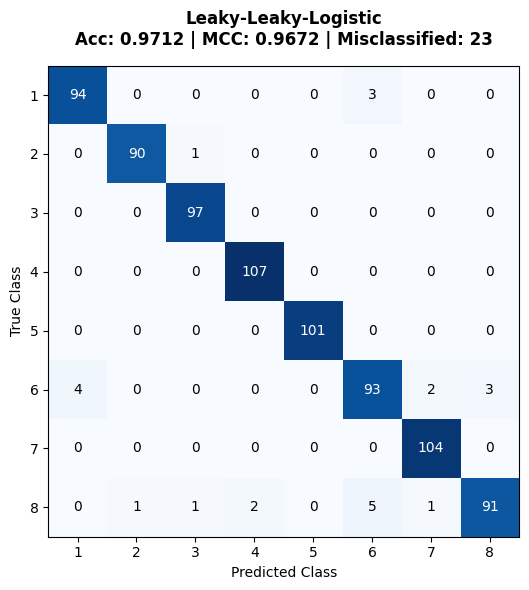


 PERFORMANCE METRICS: Leaky-Leaky-Logistic
 Accuracy:      0.9712
 MCC:           0.9672
 Misclassified: 23
-----------------------------------------------------
 Class    | Precision  | Recall     | F1-Score  
-----------------------------------------------------
 1        | 0.9592     | 0.9691     | 0.9641    
 2        | 0.9890     | 0.9890     | 0.9890    
 3        | 0.9798     | 1.0000     | 0.9898    
 4        | 0.9817     | 1.0000     | 0.9907    
 5        | 1.0000     | 1.0000     | 1.0000    
 6        | 0.9208     | 0.9118     | 0.9163    
 7        | 0.9720     | 1.0000     | 0.9858    
 8        | 0.9681     | 0.9010     | 0.9333    



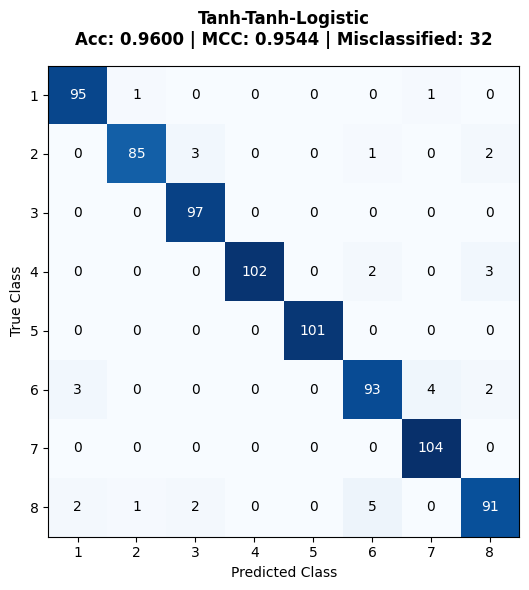


 PERFORMANCE METRICS: Tanh-Tanh-Logistic
 Accuracy:      0.9600
 MCC:           0.9544
 Misclassified: 32
-----------------------------------------------------
 Class    | Precision  | Recall     | F1-Score  
-----------------------------------------------------
 1        | 0.9500     | 0.9794     | 0.9645    
 2        | 0.9770     | 0.9341     | 0.9551    
 3        | 0.9510     | 1.0000     | 0.9749    
 4        | 1.0000     | 0.9533     | 0.9761    
 5        | 1.0000     | 1.0000     | 1.0000    
 6        | 0.9208     | 0.9118     | 0.9163    
 7        | 0.9541     | 1.0000     | 0.9765    
 8        | 0.9286     | 0.9010     | 0.9146    



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_metrics(metrics, model_name="Neural Network"):
    cm = metrics['confusion_matrix']
    precision = metrics['precision']
    recall = metrics['recall']
    f1_score = metrics['f1_score']
    accuracy = float(metrics['accuracy'])
    mcc = float(metrics['mcc'])
    misclassified = int(metrics['misclassified'])
    
    num_classes = len(precision)
    class_labels = [str(i) for i in range(1, num_classes + 1)]

    # 1. Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm, cmap='Blues')
    
    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

    # Add text inside cells
    threshold = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            color = "white" if cm[i, j] > threshold else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

    plt.tight_layout()
    plt.show()

    # 2. Print overall and per-class metrics
    print(f"\n{'='*53}")
    print(f" PERFORMANCE METRICS: {model_name}")
    print(f"{'='*53}")
    print(f" Accuracy:      {accuracy:.4f}")
    print(f" MCC:           {mcc:.4f}")
    print(f" Misclassified: {misclassified}")
    print(f"{'-'*53}")
    print(f" {'Class':<8} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
    print(f"{'-'*53}")
    
    for i in range(num_classes):
        print(f" {class_labels[i]:<8} | {precision[i]:<10.4f} | {recall[i]:<10.4f} | {f1_score[i]:<10.4f}")
    print(f"{'='*53}\n")
    
plot_model_metrics(best_leaky_model.metrics, model_name="Leaky-Leaky-Logistic")
plot_model_metrics(best_tanh_model.metrics, model_name="Tanh-Tanh-Logistic")

In [86]:
def save_metrics_to_csv(metrics, model_name="Neural_Network"):
    np.savetxt(f"{model_name}_confusion_matrix.csv", metrics['confusion_matrix'], delimiter=",", fmt="%d")
    
    # 2. Save Flattened Performance Metrics
    with open(f"{model_name}_metrics.csv", "w") as f:
        f.write("Metric,Score\n")
        
        # Write overall metrics
        f.write(f"Accuracy,{float(metrics['accuracy']):.6f}\n")
        f.write(f"MCC,{float(metrics['mcc']):.6f}\n")
        f.write(f"Misclassified,{int(metrics['misclassified'])}\n")
        
        # Flatten and write per-class metrics (1-indexed for Classes 1-8)
        num_classes = len(metrics['precision'])
        
        for i in range(num_classes):
            f.write(f"Precision-{i+1},{metrics['precision'][i]:.6f}\n")
            
        for i in range(num_classes):
            f.write(f"Recall-{i+1},{metrics['recall'][i]:.6f}\n")
            
        for i in range(num_classes):
            f.write(f"F1_Score-{i+1},{metrics['f1_score'][i]:.6f}\n")

    print(f"Metrics saved to {model_name}_metrics.csv and {model_name}_confusion_matrix.csv")

save_metrics_to_csv(best_leaky_model.metrics, model_name="Leaky-Leaky-Logistic")
save_metrics_to_csv(best_tanh_model.metrics, model_name="Tanh-Tanh-Logistic")

Metrics saved to Leaky-Leaky-Logistic_metrics.csv and Leaky-Leaky-Logistic_confusion_matrix.csv
Metrics saved to Tanh-Tanh-Logistic_metrics.csv and Tanh-Tanh-Logistic_confusion_matrix.csv


## Final Run

Now that we found the best model, let's save its weights and run the test set on it. First let's save it as what the homeworks wants us to do.

In [76]:
with open("test_set.csv", 'r') as f:
    x_test = np.loadtxt(f, delimiter=",")

In [77]:
best_leaky_model_run = MLP(
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[LeakyReLU(), LeakyReLU(), Logistic()],
    load_path=f"{best_leaky_model.results_path}/best_weights.csv",
)

leaky_predictions = best_leaky_model_run.run(x_test)

Weights successfully loaded and mapped from /home/elis/Projects/School/ai201/nn/results/leaky-leaky-logistic-300-300-best/best_weights.csv


In [78]:
best_tanh_model_run = MLP(
    input_size=354,
    output_size=8,
    hidden_layers=[300, 300],
    activations=[Tanh(), Tanh(), Logistic()],
    load_path=f"{best_tanh_model.results_path}/best_weights.csv",
)

tanh_predictions = best_tanh_model_run.run(x_test)

Weights successfully loaded and mapped from /home/elis/Projects/School/ai201/nn/results/tanh-tanh-logistic-300-300-best/best_weights.csv


In [81]:
with open("predictions_for_test_tanh.csv", "w") as f:
    np.savetxt(f, tanh_predictions, delimiter=",", fmt="%d")
with open("predictions_for_test_leaky.csv", "w") as f:
    np.savetxt(f, leaky_predictions, delimiter=",", fmt="%d")